# Deep Variational Encoder

## Imports

In [1]:
import sys
import os
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
os.environ["ENABLE_PJRT_COMPATIBILITY"] = "1"


from model import VaDE
from train import VaDE_trainer
from utils import image_to_jax1d, jax_collate_fn, plot_image

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
from flax import nnx
import optax
import pcax
import matplotlib.pyplot as plt

os.environ['JAX_PLATFORMS'] = 'cpu'

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal

## Training model

In [3]:
train_dataset = MNIST(root = "./../data", train = True, download = True, transform = image_to_jax1d)
test_dataset = MNIST(root = "./../data", train = False, download = True, transform = image_to_jax1d)

train_data_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)
test_data_loader = DataLoader(test_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)

In [4]:
in_dim         = 28*28
latent_dim     = 16
hidden_dim     = 256
rngs           = nnx.Rngs(0)
learning_rate  = 0.001
K              = 10
epochs_pretrain = 10   # Phase 1 — VAE warmup avec prior N(0,I)
epochs_finetune = 10   # Phase 3 — VaDE ELBO complet


In [5]:
model = VaDE(in_dim = in_dim, latent_dim = latent_dim, hidden_dim = hidden_dim, K = K, rngs = rngs)
optimizer = nnx.Optimizer(model, optax.adam(learning_rate), wrt = nnx.Param)
trainer = VaDE_trainer(model, optimizer)

In [6]:
# Phase 1 — Pré-entraînement VAE (prior gaussien N(0,I), KL en forme fermée)
pre_train_history, pre_eval_history = trainer.pretrain(
    epochs_pretrain, train_data_loader, test_data_loader
)

# Phase 2 — Initialisation K-means des paramètres GMM
kmeans_labels = trainer.init_gmm_kmeans(train_data_loader)

# Phase 3 — Fine-tuning avec l'ELBO VaDE complet
train_history, eval_history = trainer.train(
    epochs_finetune, train_data_loader, test_data_loader
)


Pre-training (VAE warmup):   0%|          | 0/10 [00:00<?, ?it/s]

Pre-training (VAE warmup): 100%|██████████| 10/10 [05:42<00:00, 34.23s/it]


K-means initialisation: encoding training set …


Running K-means with K=10 on 60000 points …
K-means done — cluster sizes: [4054, 7435, 5689, 6468, 5867, 5997, 4073, 5400, 8346, 6671]


Fine-tuning (VaDE): 100%|██████████| 10/10 [05:50<00:00, 35.03s/it]


In [7]:
# Correspondance clusters K-means / chiffres vrais
true_labels = np.concatenate([batch[1] for batch in train_data_loader])
print(f"Distribution des chiffres par cluster K-means :")
print(f"{'Cluster':>8}", end="")
for d in range(10): print(f"  {d:>4}", end="")
print()
for k in range(K):
    mask = kmeans_labels == k
    print(f"k={k:>6}", end="")
    for d in range(10):
        print(f"  {(true_labels[mask] == d).sum():>4}", end="")
    dominant = int(np.bincount(true_labels[mask]).argmax())
    print(f"   → dominant : {dominant}")


Distribution des chiffres par cluster K-means :
 Cluster     0     1     2     3     4     5     6     7     8     9
k=     0   394   468   361   449   394   348   395   454   368   423   → dominant : 1
k=     1   747   820   743   777   714   653   775   756   708   742   → dominant : 1
k=     2   577   616   563   593   594   528   537   574   544   563   → dominant : 1
k=     3   585   714   648   688   615   584   637   656   666   675   → dominant : 1
k=     4   590   678   624   559   532   531   574   621   601   557   → dominant : 1
k=     5   600   678   578   594   588   553   575   646   602   583   → dominant : 1
k=     6   392   488   428   409   387   344   409   427   383   406   → dominant : 1
k=     7   538   601   519   533   531   504   537   569   533   535   → dominant : 1
k=     8   838   959   815   868   826   743   809   874   807   807   → dominant : 1
k=     9   662   720   679   661   661   633   670   688   639   658   → dominant : 1


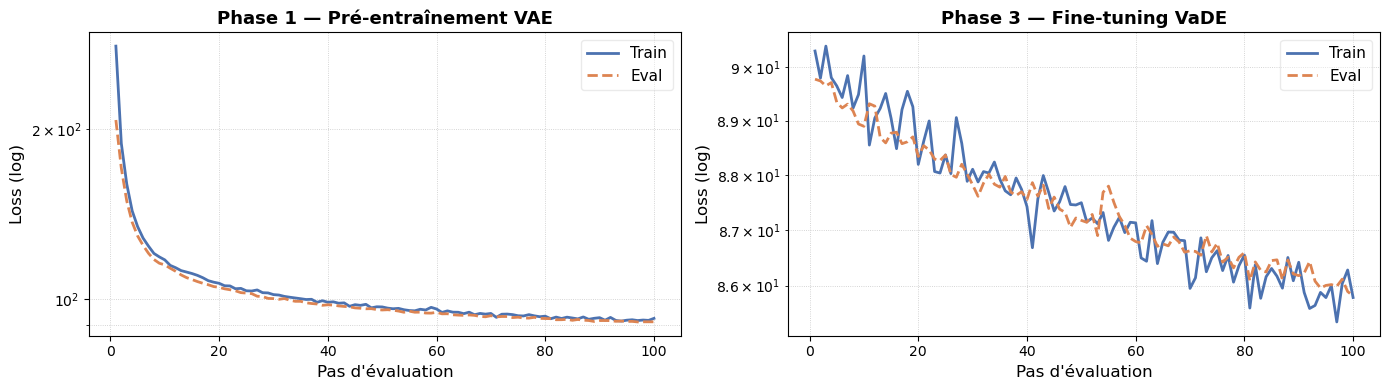

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Phase 1 : pré-entraînement ──
ax = axes[0]
r  = range(1, len(pre_train_history) + 1)
ax.plot(r, pre_train_history, color="#4C72B0", linewidth=2, label="Train")
ax.plot(r, pre_eval_history,  color="#DD8452", linewidth=2, linestyle="--", label="Eval")
ax.set_yscale("log")
ax.set_xlabel("Pas d'évaluation", fontsize=12)
ax.set_ylabel("Loss (log)", fontsize=12)
ax.set_title("Phase 1 — Pré-entraînement VAE", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

# ── Phase 3 : fine-tuning VaDE ──
ax = axes[1]
r  = range(1, len(train_history) + 1)
ax.plot(r, train_history, color="#4C72B0", linewidth=2, label="Train")
ax.plot(r, eval_history,  color="#DD8452", linewidth=2, linestyle="--", label="Eval")
ax.set_yscale("log")
ax.set_xlabel("Pas d'évaluation", fontsize=12)
ax.set_ylabel("Loss (log)", fontsize=12)
ax.set_title("Phase 3 — Fine-tuning VaDE", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

fig.tight_layout()
plt.show()


## Reconstruction test

In [9]:
x = next(iter(train_data_loader))[0][:5]
keys = jr.split(jr.PRNGKey(0), 5)
x_rec = jax.vmap(lambda xi, k: model(xi, k))(x, keys)

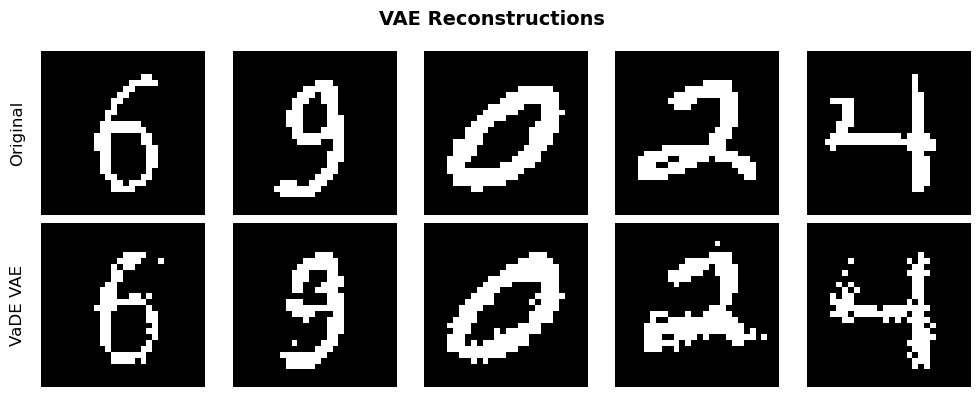

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

row_labels = ["Original", "VaDE VAE"]
rows = [x, x_rec]

for row_idx, (label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        plot_image(row_data[col_idx], ax=ax)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.1, 0.5, label,
        transform=axes[row_idx, 0].transAxes,
        fontsize=12, va="center", ha="right", rotation=90
    )

fig.suptitle("VAE Reconstructions", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Image generation

In [11]:
keys = jr.split(jr.PRNGKey(3), 5)
gen  = jnp.stack([model.generate(k)  for k in keys])

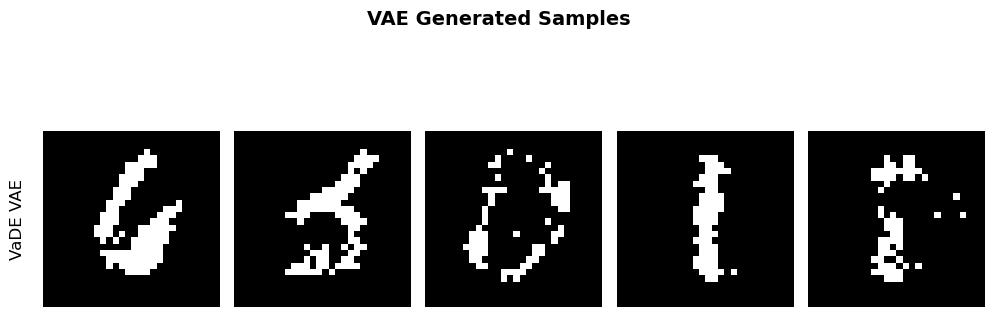

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(10, 4))

row_label = "VaDE VAE"
row_data = gen

for col_idx in range(5):
    ax = axes[col_idx]
    plot_image(row_data[col_idx], ax=ax)
    ax.axis("off")
axes[0].text(
    -0.1, 0.5, row_label,
    transform=axes[0].transAxes,
    fontsize=12, va="center", ha="right", rotation=90
)

fig.suptitle("VAE Generated Samples", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Visualization of latent space

In [13]:
x = jnp.concatenate([batch[0] for batch in train_data_loader], axis=0)
labels = jnp.concatenate([batch[1] for batch in train_data_loader], axis=0)

In [14]:
keys = jr.split(jr.PRNGKey(0), x.shape[0])
z = jax.vmap(model.encode)(x, keys)


In [15]:
state = pcax.fit(z, n_components=2)
z_pca = pcax.transform(state, z)

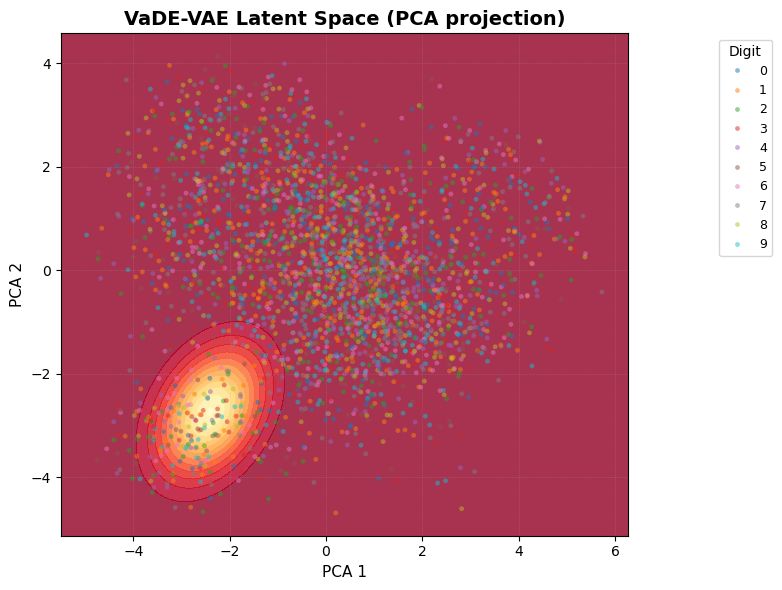

In [16]:
N_SCATTER = 3000

def make_df(z_pca, labels, n=N_SCATTER):
    idx = np.random.choice(len(z_pca), size=n, replace=False)
    return pd.DataFrame({
        "PCA 1": np.array(z_pca[idx, 0]),
        "PCA 2": np.array(z_pca[idx, 1]),
        "Digit": np.array(labels[idx]).astype(str),
    })

df = make_df(z_pca, labels)

# Recover PCA projection matrix V (latent_dim x 2) from the data
z_np = np.array(z)
z_pca_np = np.array(z_pca)
z_mean = z_np.mean(axis=0)
V, _, _, _ = np.linalg.lstsq(z_np - z_mean, z_pca_np, rcond=None)  # (latent_dim, 2)

# Build grid over the data range
x_min, x_max = df["PCA 1"].min(), df["PCA 1"].max()
y_min, y_max = df["PCA 2"].min(), df["PCA 2"].max()
margin_x, margin_y = (x_max - x_min) * 0.05, (y_max - y_min) * 0.05
xx, yy = np.meshgrid(
    np.linspace(x_min - margin_x, x_max + margin_x, 100),
    np.linspace(y_min - margin_y, y_max + margin_y, 100),
)
grid_2d = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (n_pts, 2)

# Inverse PCA: map 2D grid points back to latent space
grid_latent = jnp.array(z_mean + grid_2d @ V.T)  # (n_pts, latent_dim)

# Evaluate the VaDE prior density on the grid using model.prior_pdf
zz = np.array(jax.vmap(model.prior_pdf)(grid_latent)).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)
# Removed color bar as requested

sns.scatterplot(
    data=df, x="PCA 1", y="PCA 2", hue="Digit",
    palette=sns.color_palette("tab10", 10), alpha=0.5, s=12, linewidth=0,
    hue_order=[str(i) for i in range(10)], ax=ax,
)

ax.set_title("VaDE-VAE Latent Space (PCA projection)", fontsize=14, fontweight="bold")
ax.set_xlabel("PCA 1", fontsize=11)
ax.set_ylabel("PCA 2", fontsize=11)
ax.legend(title="Digit", bbox_to_anchor=(1.15, 1), loc="upper left", fontsize=9)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
fig.tight_layout()
plt.show()

In [17]:
alphas = jax.nn.softmax(model.logit_alpha_gmm.get_value())
mu = model.mu_gmm.get_value()


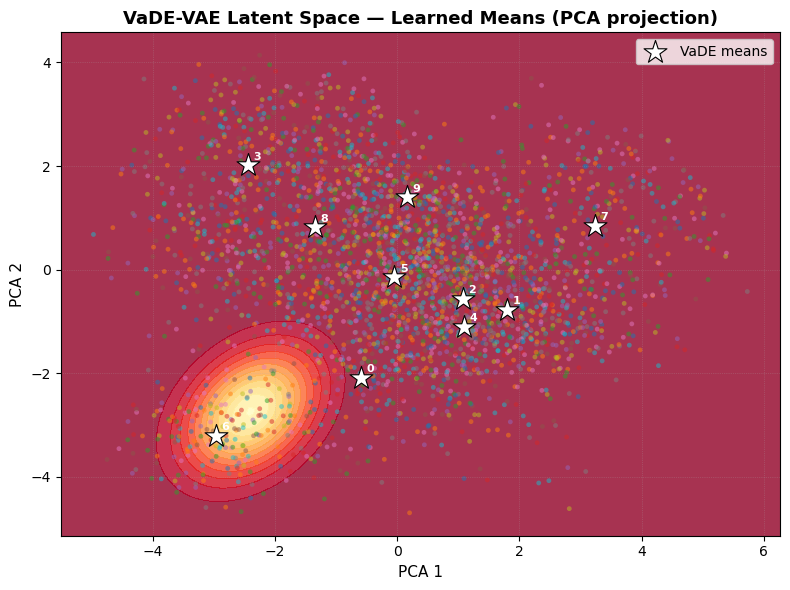

In [18]:
# Project mu_VaDE to 2D PCA space (reuses z_mean and V from the PCA cell)
mu_np = np.array(mu)
mu_pca = (mu_np - z_mean) @ V  # (K, 2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)

sns.scatterplot(
    data=df, x="PCA 1", y="PCA 2", hue="Digit",
    palette=sns.color_palette("tab10", 10), alpha=0.5, s=12, linewidth=0,
    hue_order=[str(i) for i in range(10)], ax=ax, legend=False,
)

ax.scatter(
    mu_pca[:, 0], mu_pca[:, 1],
    marker="*", s=300, c="white", edgecolors="black", linewidths=0.8,
    zorder=5, label="VaDE means",
)
for k in range(len(mu_pca)):
    ax.annotate(str(k), xy=(mu_pca[k, 0], mu_pca[k, 1]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=8, color="white", fontweight="bold")

ax.set_title("VaDE-VAE Latent Space — Learned Means (PCA projection)", fontsize=13, fontweight="bold")
ax.set_xlabel("PCA 1", fontsize=11)
ax.set_ylabel("PCA 2", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
fig.tight_layout()
plt.show()

## Visualisation de l'espace latent — UMAP

In [21]:
from umap import UMAP as UMAP_reducer

N_UMAP = 5000
np.random.seed(42)
umap_idx = np.random.choice(len(z), size=N_UMAP, replace=False)

reducer   = UMAP_reducer(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
z_umap    = reducer.fit_transform(np.array(z[umap_idx]))


/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


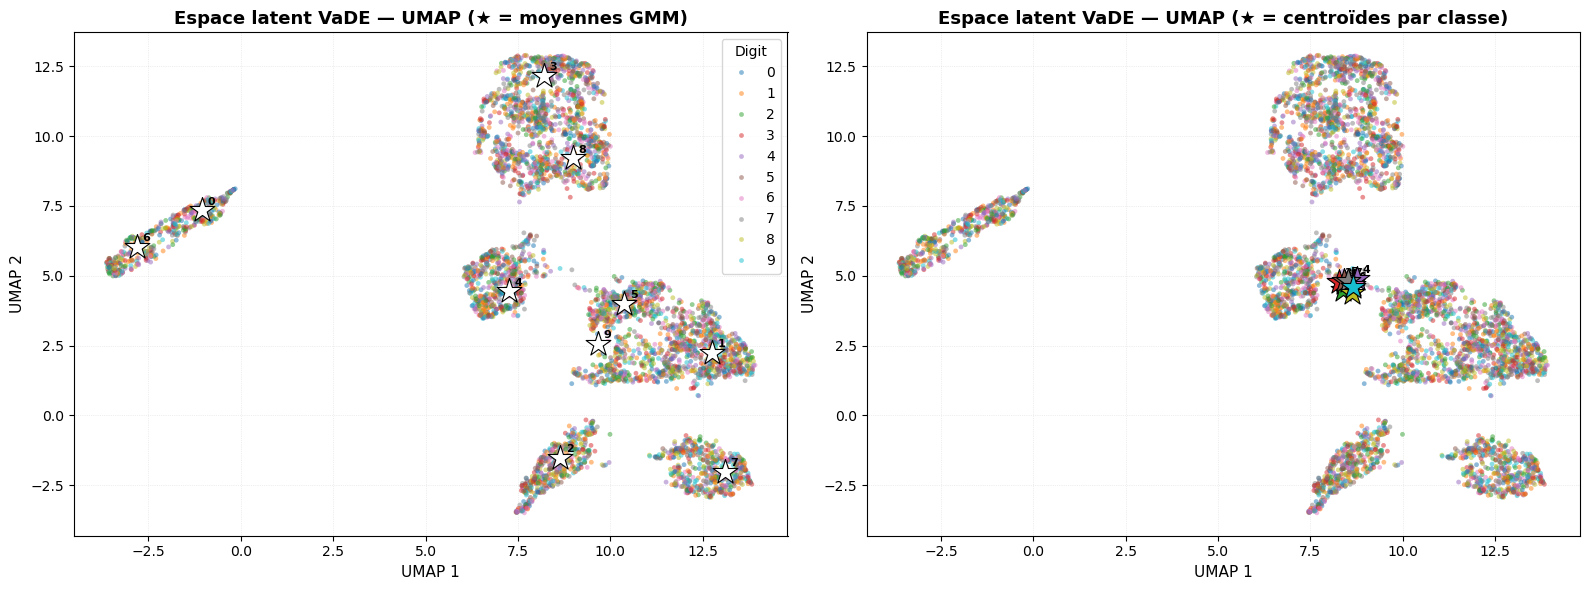

In [22]:
palette   = sns.color_palette("tab10", 10)
labels_sub = np.array(labels[umap_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Gauche : points colorés par chiffre + centroïdes GMM ──────────────────
ax = axes[0]
df = pd.DataFrame({
    "UMAP 1": z_umap[:, 0],
    "UMAP 2": z_umap[:, 1],
    "Digit":  labels_sub.astype(str),
})
sns.scatterplot(
    data=df, x="UMAP 1", y="UMAP 2", hue="Digit",
    palette=palette, alpha=0.5, s=12, linewidth=0,
    hue_order=[str(i) for i in range(10)], ax=ax,
)
# Moyennes GMM projetées via UMAP transform
mu_np   = np.array(model.mu_gmm.get_value())
mu_umap = reducer.transform(mu_np)
ax.scatter(mu_umap[:, 0], mu_umap[:, 1],
           marker="*", s=350, c="white", edgecolors="black", linewidths=0.8, zorder=5)
for k in range(len(mu_umap)):
    ax.annotate(str(k), xy=(mu_umap[k, 0], mu_umap[k, 1]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=8, color="black", fontweight="bold")
ax.set_title("Espace latent VaDE — UMAP (★ = moyennes GMM)", fontsize=13, fontweight="bold")
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)

# ── Droite : centroïdes par classe (pour évaluer l'alignement cluster/chiffre) ──
ax = axes[1]
sns.scatterplot(
    data=df, x="UMAP 1", y="UMAP 2", hue="Digit",
    palette=palette, alpha=0.5, s=12, linewidth=0,
    hue_order=[str(i) for i in range(10)], ax=ax, legend=False,
)
for d in range(10):
    mask = labels_sub == d
    if mask.sum() > 0:
        cx, cy = z_umap[mask, 0].mean(), z_umap[mask, 1].mean()
        ax.scatter(cx, cy, marker="*", s=350,
                   c=[palette[d]], edgecolors="black", linewidths=0.8, zorder=5)
        ax.annotate(str(d), xy=(cx, cy), xytext=(4, 4),
                    textcoords="offset points", fontsize=8, fontweight="bold")
ax.set_title("Espace latent VaDE — UMAP (★ = centroïdes par classe)", fontsize=13, fontweight="bold")
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)

fig.tight_layout()
plt.show()


## Génération améliorée — Moyenne du décodeur

Plutôt que de tirer un échantillon de Bernoulli pixel par pixel, on affiche directement \theta(x|z)$ : image en niveaux de gris, sans bruit de discrétisation.

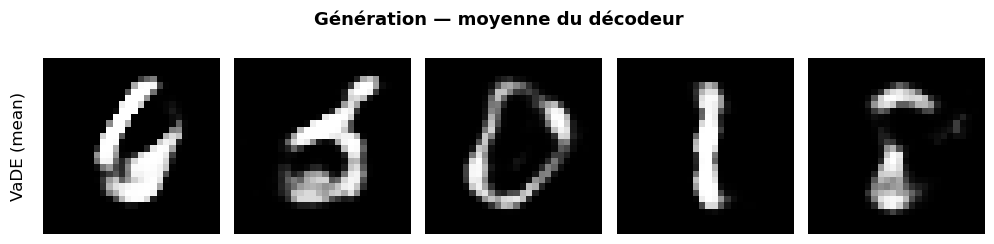

In [19]:
# generate_mean() retourne la probabilité du décodeur — image lisse
keys = jr.split(jr.PRNGKey(3), 5)
gen_mean = jnp.stack([model.generate_mean(k) for k in keys])

fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
for col_idx in range(5):
    plot_image(gen_mean[col_idx], ax=axes[col_idx])
    axes[col_idx].axis("off")
axes[0].text(-0.1, 0.5, "VaDE (mean)",
             transform=axes[0].transAxes,
             fontsize=12, va="center", ha="right", rotation=90)
fig.suptitle("Génération — moyenne du décodeur", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Génération conditionnelle par composante GMM

Chaque ligne correspond à une composante du prior GMM (style Figure 3(d) du papier VaDE).

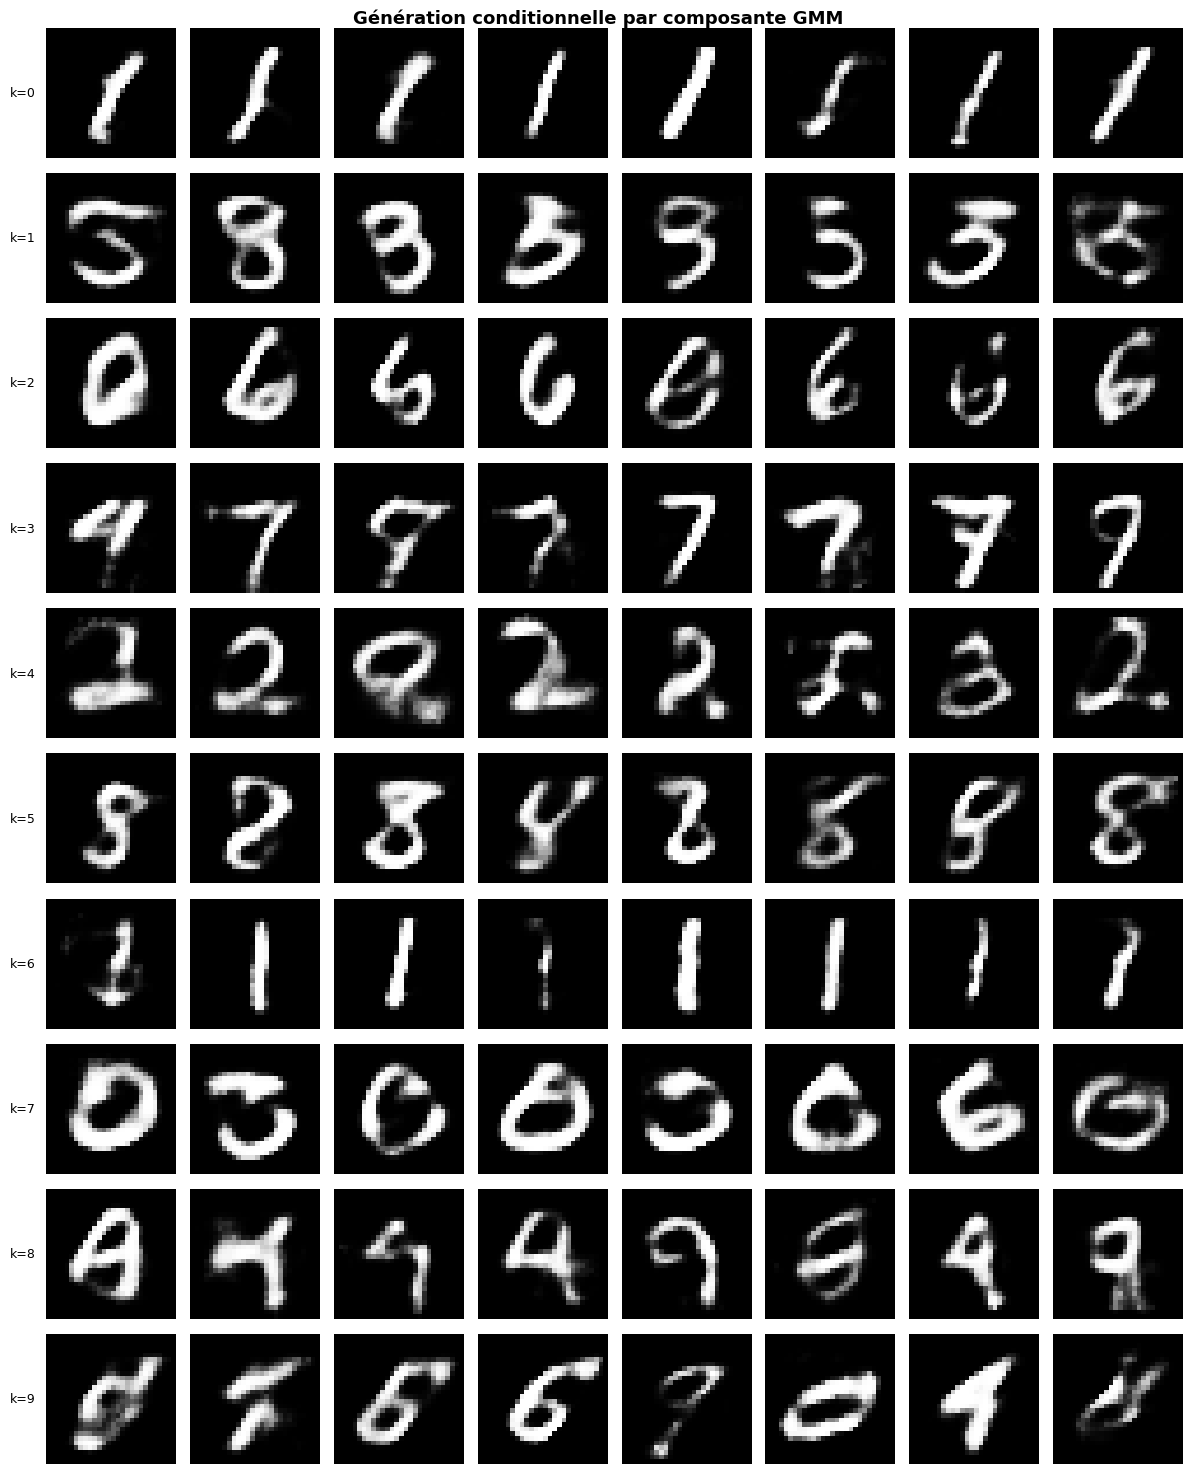

In [20]:
N_SAMPLES = 8   # images par composante

fig, axes = plt.subplots(model.K, N_SAMPLES, figsize=(N_SAMPLES * 1.5, model.K * 1.5))

for k in range(model.K):
    keys_k = jr.split(jr.PRNGKey(k * 100), N_SAMPLES)
    for j in range(N_SAMPLES):
        img = model.generate_from_component(keys_k[j], component=k)
        plot_image(img, ax=axes[k, j])
        axes[k, j].axis("off")
    axes[k, 0].text(-0.08, 0.5, f"k={k}",
                    transform=axes[k, 0].transAxes,
                    fontsize=9, va="center", ha="right")

fig.suptitle("Génération conditionnelle par composante GMM", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()